# PatchGuard: A Robust, Adaptive Defense for Image Classifiers

## Meta Info

To get start, make a copy of this notebook to your own Google Drive, then work on this assignment in that notebook. Make sure to share your notebook (Viewer access to everyone) when you finished it, and include the link to it below so we can access it.
```
Group members: Eleanor Liu, Peiyang Xu

Link to your Colab Notebook: https://colab.research.google.com/drive/1HaQRd_GiFDF0MAHoS9F5dCp_9wTdUEyb?usp=sharing
```

## Introduction

In this assignment, you'll learn about how image classifiers can be attacked and how they can then be made more robust against attacks.
Specifically, you will learn about **patch-based attacks** which are inference time attacks that can be realized in the physical world.
You will then explore how **redundancy-based defenses** like PatchGuard can protect against such attacks and how they can be practically deployed in real-world contexts.

To learn more about this defense, also known as PatchGuard, you can read more about it [here](https://www.usenix.org/system/files/sec21-xiang.pdf) and its follow-up work, PatchCleanser, [here](https://arxiv.org/pdf/2108.09135).

As in previous assignments, we will provide helper code and clearly indicate which functions you need to implement using the following annotation:

```
# TODO: write your code here
```
Moreover, there is a set of reflection questions in part 6 that you must answer. All required text responses will be denoted by **WRITE YOUR ANSWER HERE**.


This assignment does not assume you must have taken prior coursework or have in-depth experience with machine learning.
To focus on the core concepts of the assignment, we abstract away  low-level details through pre-implemented helper functions that allow you to interact with the machine learning models (e.g., during training and testing).


## 0. Getting Started

Make a copy of this notebook so you can edit the assignment directly.

Change the Hardware to GPU by going to Runtime > Change Runtime Type > Hardware Accelerator and set it to T4 GPU.

**IMPORTANT:** Although there is nothing to implement or answer in Section 0 and its subsections, read the subsection descriptions carefully to familiarize yourself with the assignment specifications.

### 0.1. Install Libraries
Run the following block of code to install the required libraries.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

### 0.2. Load Datasets
Run the following block of code to load the MNIST training and test datasets.

**MNIST** is a dataset of 28×28 pixel grayscale images of hand-written digits (0-9), where each image is labeled by the digit it represents.

There is nothing to implement or answer in this step.


In [2]:
device = "cuda"
epochs_baseline = 30
epochs_pg = 100
n_examples_train = 3000
n_examples_test = 500
data_dir = "./data"
batch_size=10

def load_subset(dataset, n, device):
    xs = torch.stack([dataset[i][0] for i in range(n)])
    ys = torch.tensor([dataset[i][1] for i in range(n)])
    return xs.to(device), ys.to(device)


# load MNIST data
train = datasets.MNIST(root=data_dir, train=True, download=True, transform=transforms.ToTensor())
test = datasets.MNIST(root=data_dir, train=False, download=True, transform=transforms.ToTensor())

train_images, train_labels = load_subset(train, n_examples_train, device)
test_images_clean, test_labels = load_subset(test, n_examples_test, device)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


### 0.2. Setup Patch Attack & PatchGuard Parameters
Run the following block of code to setup the patch attack and PatchGuard parameters. In the reflection questions, you will be asked to explore different parameters.

There is nothing to implement or answer in this step.


In [3]:
# -----------------------------------------------------------------------------
# Patch attack parameters
# -----------------------------------------------------------------------------

# Size (in pixels) of the adversarial patch (size x size)
patch_sizes = [12,]

# Step size (in pixels) when sliding the patch across the image
# Smaller stride = more overlap
strides = [2,]

# Size (in pixels) of the window (window_size x window_size) PatchGuard model predicts on
window_sizes = [16,]

# Offsets (in pixels) from the image center where the patch is placed
patch_x = [12,]
patch_y = [12,]

### 0.3. Prepare Baseline Models

Run the following blocks of code to prepare the **baseline (i.e., unprotected)** image classifiers for the MNIST dataset.

For **MNIST**, we train a small neural network based on the classic **LeNet** architecture.  
LeNet is one of the earliest neural networks designed for recognizing handwritten digits.

If you are interested, you can read more about it [here](https://www.geeksforgeeks.org/computer-vision/what-is-lenet/).

There is nothing to implement or answer in this step.



In [4]:
# -----------------------------------------------------------------------------
# Basic CNN Image Classifier (based on the classic LeNet architecture)
#
# This neural network takes an image as input and predicts which class
# the image belongs to (e.g., which digit in MNIST).
# -----------------------------------------------------------------------------
class BasicCNN(nn.Module):
    def __init__(self, patch_size, in_channels, channels=(32, 64), fc_dim=128, num_classes=10):
        super().__init__()

        c1, c2 = channels
        feat_dim = c2 * (patch_size // 4) * (patch_size // 4)

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(feat_dim, fc_dim),
            nn.ReLU(),
            nn.Linear(fc_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# -----------------------------------------------------------------------------
# Train a model on a dataset
#
# The model repeatedly looks at batches of training images and gradually
# improves its predictions by minimizing classification error.
# -----------------------------------------------------------------------------
def train_model(model, x, y, epochs):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    N = x.size(0)

    for epoch in range(epochs):
        perm = torch.randperm(N)
        epoch_loss = 0.0

        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]

            inputs = x[idx].to(device)
            labels = y[idx].to(device)

            logits = model(inputs)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch:02d} | "f"avg loss = {epoch_loss / (N // batch_size):.4f}")

In [5]:

# -----------------------------------------------------------------------------
# Create and train baseline MNIST image classifier
# -----------------------------------------------------------------------------
baseline_model = BasicCNN(patch_size=train_images.size(-1), in_channels = train_images.size(1)).to(device)
train_model(baseline_model, train_images, train_labels, epochs_baseline)

Epoch 00 | avg loss = 0.6770
Epoch 01 | avg loss = 0.1830
Epoch 02 | avg loss = 0.1076
Epoch 03 | avg loss = 0.0676
Epoch 04 | avg loss = 0.0470
Epoch 05 | avg loss = 0.0415
Epoch 06 | avg loss = 0.0136
Epoch 07 | avg loss = 0.0157
Epoch 08 | avg loss = 0.0052
Epoch 09 | avg loss = 0.0026
Epoch 10 | avg loss = 0.0298
Epoch 11 | avg loss = 0.0301
Epoch 12 | avg loss = 0.0044
Epoch 13 | avg loss = 0.0009
Epoch 14 | avg loss = 0.0003
Epoch 15 | avg loss = 0.0003
Epoch 16 | avg loss = 0.0001
Epoch 17 | avg loss = 0.0001
Epoch 18 | avg loss = 0.0000
Epoch 19 | avg loss = 0.0000
Epoch 20 | avg loss = 0.0000
Epoch 21 | avg loss = 0.0000
Epoch 22 | avg loss = 0.0000
Epoch 23 | avg loss = 0.0000
Epoch 24 | avg loss = 0.0000
Epoch 25 | avg loss = 0.0000
Epoch 26 | avg loss = 0.0000
Epoch 27 | avg loss = 0.0000
Epoch 28 | avg loss = 0.0000
Epoch 29 | avg loss = 0.0000


### 0.4. Generate Adversarially-Perturbed Images

Run the following blocks of code to generate **adversarial images**.

An *adversarial image* is created by modifying a small region of an image so that a classifier makes an incorrect prediction.
In this assignment, the modification is a **k × k patch**, where the pixels inside the patch can take arbitrary values.

The code below automatically computes a patch that causes the model to misclassify each image.

In the original **PatchGuard** paper, the attacker is allowed to place the patch **anywhere in the image**. For simplicity in this assignment, we instead **fix the patch location** during image generation.

There is nothing to implement or answer in this step.


In [6]:
# -----------------------------------------------------------------------------
# Generate Adversarial Images with Patch Attacks
#
# This function creates adversarial images by adding a small k×k patch
# to each input image. The patch is optimized so that the classifier
# is more likely to make an incorrect prediction.
#
# In the full PatchGuard threat model, an attacker can place the patch
# anywhere in the image. For simplicity in this assignment, we fix the
# patch location near the center of the image.
#
# The algorithm repeatedly adjusts the patch pixel values to increase
# the model's classification error on the patched image.
# -----------------------------------------------------------------------------
def generate_adversarial_img(model, x, y, patch_size, patch_x, patch_y, steps=20, step_size=8/255):
    patch_eps=1.0

    B, C, H, W = x.shape

    # Choose a fixed patch location (near the center of the image)
    r = H // 2 - patch_y
    c = W // 2 - patch_x
    patch_slice = (slice(None), slice(None), slice(r, r + patch_size), slice(c, c + patch_size))

    # Initialize patch with zeros
    patch = torch.zeros(B, C, patch_size, patch_size, device=x.device, requires_grad=True)
    # Optimize the patch only
    x_base = x.detach()

    # Iteratively update the patch to make the model misclassify the image
    for _ in range(steps):
        # Insert patch onto image
        patched = x_base.clone()
        patched[patch_slice] = (patched[patch_slice] + patch).clamp(0, 1)

        # Compute loss on patched image to maximize misclassification
        loss = F.cross_entropy(model(patched), y)
        loss.backward()

        # Update patch
        with torch.no_grad():
            patch.add_(step_size * patch.grad.sign()) # Gradient ascent
            patch.clamp_(-patch_eps, patch_eps) # Constrains patch magnitude for stable training
            patch.grad.zero_()

    # Save adversarial image + patch
    x_adv = x_base.clone()
    x_adv[patch_slice] = (x_adv[patch_slice] + patch).clamp(0, 1)

    return x_adv

# -----------------------------------------------------------------------------
# Generate adversarial images for MNIST
# -----------------------------------------------------------------------------
test_images_adv = generate_adversarial_img(baseline_model,
                                           test_images_clean,
                                           test_labels,
                                           patch_sizes[0],
                                           patch_x[0], patch_y[0])

## 1. A Motivating Example
### 1.2. The Effect of Benign vs Adversarial Inputs on Non-PatchGuard Image Classifiers

Before diving into the assignment, let us first examine a motivating example that demonstrates how **unmitigated image classifiers can fail when given adversarial inputs**.

There is nothing to implement or answer in this step.

First, consider how the MNIST classifier performs on a **benign (clean) input image**.
In this setting, the model receives an unmodified image from the dataset and typically predicts the correct label.


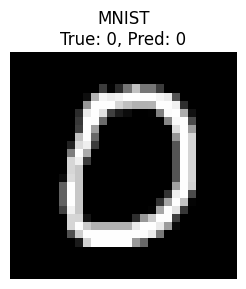

In [7]:
# -----------------------------------------------------------------------------
# Visualize Clean MNIST Image (single plot)
# -----------------------------------------------------------------------------
def show_clean_image(model, img, label):
    model.eval()

    with torch.no_grad():
        pred = model(img.unsqueeze(0)).argmax(dim=1).item()

    img = img.detach().cpu()

    plt.figure(figsize=(3, 3))
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"MNIST\nTrue: {label}, Pred: {pred}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------------
# Example clean image
# -------------------------------------------------------------------------
idx = 10
show_clean_image(baseline_model, test_images_clean[idx], test_labels[idx])

Now we compare this to an **adversarially perturbed version of the same image**.  
In this example, a small **k × k patch** has been inserted into the image. Although the patch only modifies a small region, it is carefully constructed to cause the classifier to make an incorrect prediction.

This example highlights an important security concern.
Even though a **human observer may still correctly recognize the image**, the classifier is easily manipulated by a small localized perturbation.

Such vulnerabilities can be dangerous in real-world systems.
For example, in autonomous driving, attackers can place a small sticker on a **stop sign** causing vision systems to misclassify it as a different object, potentially leading to unsafe behavior.

However, play around with the `idx` variable in the previous code block (and rerun both code blocks) to see other examples (e.g., `idx=7`) of adversarial perturbations that even we as humans may not be able to classify correctly.
Think about how this may also affect how we use "robust accuracy" as defined in part 5.

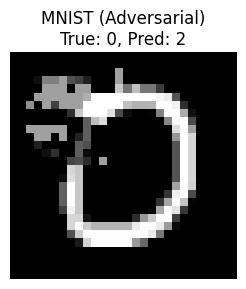

In [8]:
# -----------------------------------------------------------------------------
# Visualize Adversarial MNIST Image (single plot)
# -----------------------------------------------------------------------------
def show_adversarial_image(model, img_adv, label):
    model.eval()

    with torch.no_grad():
        pred = model(img_adv.unsqueeze(0)).argmax(dim=1).item()

    img_adv = img_adv.detach().cpu()

    plt.figure(figsize=(3, 3))
    plt.imshow(img_adv.squeeze(), cmap="gray")
    plt.title(f"MNIST (Adversarial)\nTrue: {label}, Pred: {pred}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------------
# Example adversarial image
# -------------------------------------------------------------------------
show_adversarial_image(baseline_model, test_images_adv[idx], test_labels[idx])

### 1.2. PatchGuard
We just observed how a small adversarial patch can break the classifier, causing it to produce incorrect predictions.
This type of vulnerability is exactly what **PatchGuard** is designed to defend against.

PatchGuard improves robustness to adversarial patches by making predictions based on **smaller regions of an image**, also known as a **window**, rather than processing the full image at once.
The PatchGuard process is as follows:
1. Divide the image into windows
    - the image is split into multiple (possibly overlapping) windows
2. Window-based classification
    - For each window, the model predicts the image class using only that window, with all other pixels zeroed out.
3. Robust aggregation
    - The predictions from all windows are combined (via majority voting) to produce a more robust final classification.

As a result, even if some windows are corrupted by the adversarial patch, the goal is that the correct predictions from unaffected windows will  dominate the final result.


## 2. Threat Model Questions

Please answer the questions below.

1. What are the attacker's goals?

The attacker's goal is to manipulate the input image so that the image classifier makes an incorrect prediction, even though the image might still be easily recognizable by a human.


2. What is the attacker's background knowledge (e.g., about the model, training data)?

The attacker operates in a white-box setting. So they have the complete knowledge of the model's architecture and weights. This allows them to compute gradients and iteratively optimize the adversarial patch to maximize the classification error.


3. What are the attacker's capabilities and in what ways are they constrained?

The attacker can changing pixel values in the target image to arbitrary values. However, they can only modify a small, localized region of the image(a single $k \times k$ patch). The rest of the image must remain unchanged. In the full threat model, they can place this patch anywhere, but in this specific assignment setup, the location must be fixed near the center.

## 3. Prepare PatchGuard Model

Next, we prepare **PatchGuard-protected version** of the MNIST classifier.

As a reminder, PatchGuard improves robustness to adversarial patches by making predictions on **windows**, rather than on the entire image at once. In particular the PatchGuard models are trained on images where all pixels outside of the window are zeroed out, whereas unmitigated models train on the full image context.

### Coding Task 1:
To implement this defense, you will complete the function **`extract_windows`**, which extracts all sliding windows from an input image. The PatchGuard model will later make predictions on each of these windows.

Your implementation should:

- Extract all windows of size **`window_size × window_size`** from the input image **`img`**
- Ensure the windows slide across the image using the specified **`stride`**
- Return the extracted windows in the format expected by the training code

Important PyTorch concepts for this assignment are tensors (multi-dimensional arrays) and common operations on them, such as accessing their dimensions using `.shape`. Here is PyTorch documentation on [tensors](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html).
- Image data are typically represented as 3D tensors with shape C × H × W, where:
  - C = number of channels (e.g., 1 for MNIST which is greyscale)
  - W = width
  - H = height

Once you finish implementing this function, run the following blocks of code to **train the PatchGuard model** using these windows.

Training may take a few minutes.


In [9]:
# -----------------------------------------------------------------------------
# Extract Sliding Windows from an Image
#
# Given an input image of shape [channels, height, width], this function
# extracts all sliding windows of size [window_size × window_size] using
# the specified stride.
#
# Each window represents a small region of the image that the PatchGuard
# classifier will later use for prediction.
#
# Returns:
#   Tensor of shape [num_windows, channels, window_size, window_size]
# -----------------------------------------------------------------------------
def extract_windows(img, window_size, stride):
    C, H, W = img.shape
    windows = []
    # Slide the window across the height and width
    for y in range(0, H - window_size + 1, stride):
        for x in range(0, W - window_size + 1, stride):
            # Extract the window
            window = img[:, y:y+window_size, x:x+window_size]
            windows.append(window)
    return torch.stack(windows)


In [10]:
# -----------------------------------------------------------------------------
# Train a PatchGuard Model
#
# Unlike the baseline classifier, PatchGuard does not train directly on
# full images. Instead, each image is broken into many sliding windows.
#
# The model is trained to classify each window individually. During
# inference, PatchGuard aggregates predictions across windows to
# mitigate the effect of adversarial patches.
# -----------------------------------------------------------------------------
def train_pg_model(model, x, y, epochs, window_size, stride=None):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    N = x.size(0)

    for epoch in range(epochs):
        perm = torch.randperm(N)
        epoch_loss = 0.0

        # For each image in the batch, extract its sliding windows
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]

            window_batches = []
            label_batches = []

            for j in idx:
                img = x[j]
                label = y[j].item()

                windows = extract_windows(img, window_size, stride)
                window_batches.append(windows)
                # Each window inherits the label of the original image
                label_batches.append(torch.full((windows.size(0),), label, device=windows.device))

                inputs = torch.cat(window_batches, dim=0).to(device)
                labels = torch.cat(label_batches, dim=0).to(device)

            logits = model(inputs)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch:02d} | "f"avg loss = {epoch_loss / (N // batch_size):.4f}")

In [11]:
# -----------------------------------------------------------------------------
# Train PatchGuard Models
# -----------------------------------------------------------------------------

print("MNIST training:")
patch_model = BasicCNN(patch_size=window_sizes[0], in_channels = train_images.size(1)).to(device)
train_pg_model(patch_model, train_images, train_labels, epochs_pg, window_sizes[0], strides[0])

MNIST training:
Epoch 00 | avg loss = 1.8696
Epoch 01 | avg loss = 1.0466
Epoch 02 | avg loss = 0.7586
Epoch 03 | avg loss = 0.6331
Epoch 04 | avg loss = 0.5632
Epoch 05 | avg loss = 0.4965
Epoch 06 | avg loss = 0.4475
Epoch 07 | avg loss = 0.4217
Epoch 08 | avg loss = 0.3863
Epoch 09 | avg loss = 0.3688
Epoch 10 | avg loss = 0.3523
Epoch 11 | avg loss = 0.3377
Epoch 12 | avg loss = 0.3181
Epoch 13 | avg loss = 0.3014
Epoch 14 | avg loss = 0.2910
Epoch 15 | avg loss = 0.2816
Epoch 16 | avg loss = 0.2654
Epoch 17 | avg loss = 0.2583
Epoch 18 | avg loss = 0.2446
Epoch 19 | avg loss = 0.2381
Epoch 20 | avg loss = 0.2347
Epoch 21 | avg loss = 0.2261
Epoch 22 | avg loss = 0.2147
Epoch 23 | avg loss = 0.2106
Epoch 24 | avg loss = 0.2040
Epoch 25 | avg loss = 0.1966
Epoch 26 | avg loss = 0.1907
Epoch 27 | avg loss = 0.1811
Epoch 28 | avg loss = 0.1796
Epoch 29 | avg loss = 0.1696
Epoch 30 | avg loss = 0.1651
Epoch 31 | avg loss = 0.1602
Epoch 32 | avg loss = 0.1558
Epoch 33 | avg loss = 0.144

## 4. Implement Prediction and Accuracy Calculation Functions

Now we implement the functions needed to make predictions using PatchGuard and evaluate its performance.

Recall that PatchGuard does not classify the entire image directly. Instead, it:

1. Extracts sliding windows from the image
2. Classifies each window individually
3. Aggregates window predictions using majority voting

This aggregation helps limit the influence of a small adversarial patch, since only a subset of windows may contain the perturbed patch.

### Coding Tasks 2 & 3

Implement the following functions:

- **`patchguard_predict`** which predicts the label of a single image using PatchGuard's window-based classification and majority voting.

- **`patchguard_accuracy`** which computes the overall classification accuracy of a PatchGuard model on a dataset.

In [12]:
# helper function that takes in an array of windows and the model to classify each window
# returns an array of predictions (one per window)
def get_window_predictions(model, windows):
  with torch.no_grad():
    logits = model(windows)
    return logits.argmax(dim=1)

# -----------------------------------------------------------------------------
# PatchGuard Prediction Function
#
# Predicts the label of a single image using the PatchGuard defense.
#
# Returns:
#   Integer representing the predicted class label.
# -----------------------------------------------------------------------------
def patchguard_predict(model, img, window_size, stride):
  with torch.no_grad():
    # 1) extract all windows from image
    windows = extract_windows(img, window_size, stride)

    # 2) classify each window using model and get each window's prediction
    windows = windows.to(next(model.parameters()).device)
    preds = get_window_predictions(model, windows)

    # 3) use majority voting over window predictions to get final label
    final_pred = torch.bincount(preds).argmax().item()

    return final_pred


In [13]:
# -----------------------------------------------------------------------------
# PatchGuard Accuracy Evaluation
#
# Computes the classification accuracy of a PatchGuard model over a dataset.
#
# For each image:
#   - Predict the label using patchguard_predict
#   - Compare it with the true label
#
# Returns:
#   Accuracy = (# correct predictions) / (# test images)
# -----------------------------------------------------------------------------
def patchguard_accuracy(model, x, y, window_size, stride):
    model.eval()
    correct = 0
    num_test_img = x.size(0)

    for i in range(num_test_img):
        pred = patchguard_predict(model, x[i], window_size, stride)
        if pred == y[i].item():
            correct += 1
    return correct / num_test_img


## 5. Evaluate Model on Benign and Adversarial Images

Finally, we evaluate how well the models perform on **benign (clean) images** and **adversarially perturbed images**.

For the MNIST dataset, we compute two metrics:

- **Clean accuracy** – accuracy on the original test images  
- **Robust accuracy** – accuracy on adversarially-perturbed test images

Comparing these metrics highlight how vulnerable unmitigated image classifiers are to adversarial patches and how robustness may inadverdently affect clean accuracy.

There is nothing to implement or answer in this step. Run the following code blocks to evaluate the models.

In [14]:
# -----------------------------------------------------------------------------
# Compute Classification Accuracy
#
# Evaluates a standard image classifier on a dataset by comparing
# predicted labels with the true labels.
#
# Returns:
#   Accuracy = (# correct predictions) / (# test images)
# -----------------------------------------------------------------------------
def accuracy(model, x, y):
    model.eval()
    correct = 0
    num_test_img = x.size(0)

    for i in range(num_test_img):
        logits = model(x[i].unsqueeze(0))
        pred = logits.argmax(dim=1)

        label = y[i].item()
        correct += int(pred == label)
    return correct / num_test_img

In [15]:
# -----------------------------------------------------------------------------
# Evaluate Baseline (Unmitigated) Model
# -----------------------------------------------------------------------------
print("Unmitigated:")
print("Clean accuracy:", accuracy(baseline_model, test_images_clean, test_labels))
print("Robust accuracy:", accuracy(baseline_model, test_images_adv, test_labels))

Unmitigated:
Clean accuracy: 0.986
Robust accuracy: 0.492


In [16]:
# -----------------------------------------------------------------------------
# Evaluate PatchGuard Model
# -----------------------------------------------------------------------------
print("PatchGuard:")
acc_clean = patchguard_accuracy(patch_model, test_images_clean, test_labels, window_sizes[0], strides[0])
print(f"Clean accuracy:    {acc_clean:.3f}")
acc_adv = patchguard_accuracy(patch_model, test_images_adv, test_labels, window_sizes[0], strides[0])
print(f"Robust accuracy:   {acc_adv:.3f}")

PatchGuard:
Clean accuracy:    0.980
Robust accuracy:   0.744


## 6. Reflection Questions

Please answer the following questions. For each question, cite accuracy statistics for **5 different values** of the parameter, while holding other parameters constant. You can adjust the parameters in part 0.2.

1. How does the size of the **sliding window** affect the unmitigated and PatchGuard model accuracies? Test out different sizes in the code block below and run it to show your results.

**Answer:**

| Window Size | PatchGuard Clean | PatchGuard Robust |
|  :---: | :---: | :---: |
| 8 | 0.642 | 0.610 |
| 12  | 0.946 | 0.832 |
| 16  | 0.974 | 0.750 |
| 20 | 0.986 | 0.690 |
| 24 | 0.976 | 0.606 |

**Analysis:**

There is a clear trade-off based on window size.

**Too small (size 8):** Clean accuracy drops to random guessing levels because an 8x8 window lacks sufficient spatial context to recognize digit features.

**Moderate/Optimal (size 12, 16):** Clean accuracy recovers, and robust accuracy peaks. The windows are large enough to classify digits correctly, but small enough that the patch only corrupts a minority of them.

**Too large (size 20, 24):** Clean accuracy stays high, but robust accuracy decreases (drops to 0.606 at size 24). Larger windows cover more area, so a higher percentage of the sliding windows will overlap with the adversarial patch. And it eventually compromise the majority voting defense.

In [17]:
# Test 5 different window sizes
test_window_sizes = [8, 12, 16, 20, 24]
fixed_stride = strides[0]

# Unmitigated model accuracies (unaffected by window size)
print("Original:")
print(f"Clean accuracy:  {accuracy(baseline_model, test_images_clean, test_labels):.3f}")
print(f"Robust accuracy: {accuracy(baseline_model, test_images_adv, test_labels):.3f}\n")

for w in test_window_sizes:
    print(f"Testing window_size: {w}")
    # Initialize
    pg_model = BasicCNN(patch_size=w, in_channels=train_images.size(1)).to(device)

    # Train the model
    train_pg_model(pg_model, train_images, train_labels, epochs_pg, w, fixed_stride)

    # Evaluate accuracy
    acc_clean = patchguard_accuracy(pg_model, test_images_clean, test_labels, w, fixed_stride)
    acc_adv = patchguard_accuracy(pg_model, test_images_adv, test_labels, w, fixed_stride)

    print(f"\nResults for window_size={w}:")
    print(f"PG Clean accuracy:    {acc_clean:.3f}")
    print(f"PG Robust accuracy:   {acc_adv:.3f}\n")


Original:
Clean accuracy:  0.986
Robust accuracy: 0.492

Testing window_size: 8
Epoch 00 | avg loss = 2.2626
Epoch 01 | avg loss = 2.1692
Epoch 02 | avg loss = 2.0897
Epoch 03 | avg loss = 2.0239
Epoch 04 | avg loss = 1.9758
Epoch 05 | avg loss = 1.9552
Epoch 06 | avg loss = 1.9264
Epoch 07 | avg loss = 1.9019
Epoch 08 | avg loss = 1.8838
Epoch 09 | avg loss = 1.8691
Epoch 10 | avg loss = 1.8567
Epoch 11 | avg loss = 1.8468
Epoch 12 | avg loss = 1.8312
Epoch 13 | avg loss = 1.8204
Epoch 14 | avg loss = 1.8153
Epoch 15 | avg loss = 1.7938
Epoch 16 | avg loss = 1.7928
Epoch 17 | avg loss = 1.7851
Epoch 18 | avg loss = 1.7760
Epoch 19 | avg loss = 1.7704
Epoch 20 | avg loss = 1.7645
Epoch 21 | avg loss = 1.7616
Epoch 22 | avg loss = 1.7555
Epoch 23 | avg loss = 1.7525
Epoch 24 | avg loss = 1.7457
Epoch 25 | avg loss = 1.7413
Epoch 26 | avg loss = 1.7313
Epoch 27 | avg loss = 1.7345
Epoch 28 | avg loss = 1.7302
Epoch 29 | avg loss = 1.7242
Epoch 30 | avg loss = 1.7239
Epoch 31 | avg loss =

2. How does the size of the **stride** affect the unmitigated and PatchGuard model accuracies? Test out different sizes in the code block below and run it to show your results.

**Answer:**

| Stride | PatchGuard Clean | PatchGuard Robust |
|  :---: | :---: | :---: |
| 1 | 0.982 | 0.746 |
| 2  | 0.980 | 0.744 |
| 4  | 0.970 | 0.754 |
| 6 | 0.966 | 0.776 |
| 8 | 0.944 | 0.592 |

**Analysis:**

There is a clear trade-off between clean accuracy and robust accuracy as the stride changes.

*   **Clean Accuracy:** As the stride increases, clean accuracy steadily decreases. A larger stride means fewer total windows are extracted from the image. With fewer windows, there is less redundant information, so the majority vote is slightly less reliable on clean images.
*   **Robust Accuracy:** Robust accuracy remains relatively stable and even peaks slightly at moderate strides (stride 6). However, if the stride becomes too large (stride 8), the robust accuracy drops significantly. This is because a larger stride generates very few windows in total. The adversarial patch will intersect with a much larger percentage of the total extracted windows, and it will eventually overwhelm the majority voting defense mechanism.

In [18]:
# Test 5 different strides
test_strides = [1, 2, 4, 6, 8]
fixed_window_size = window_sizes[0]

for s in test_strides:
    print(f"Testing stride = {s}")
    # Initialize
    pg_model = BasicCNN(patch_size=fixed_window_size, in_channels=train_images.size(1)).to(device)

    # Train the model
    train_pg_model(pg_model, train_images, train_labels, epochs_pg, fixed_window_size, s)

    # Evaluate accuracy
    acc_clean = patchguard_accuracy(pg_model, test_images_clean, test_labels, fixed_window_size, s)
    acc_adv = patchguard_accuracy(pg_model, test_images_adv, test_labels, fixed_window_size, s)

    print(f"\nResults for stride={s}:")
    print(f"PG Clean accuracy:    {acc_clean:.3f}")
    print(f"PG Robust accuracy:   {acc_adv:.3f}\n")


Testing stride = 1
Epoch 00 | avg loss = 1.7336
Epoch 01 | avg loss = 0.8878
Epoch 02 | avg loss = 0.6519
Epoch 03 | avg loss = 0.5573
Epoch 04 | avg loss = 0.4918
Epoch 05 | avg loss = 0.4500
Epoch 06 | avg loss = 0.4128
Epoch 07 | avg loss = 0.3769
Epoch 08 | avg loss = 0.3614
Epoch 09 | avg loss = 0.3352
Epoch 10 | avg loss = 0.3200
Epoch 11 | avg loss = 0.3048
Epoch 12 | avg loss = 0.2914
Epoch 13 | avg loss = 0.2756
Epoch 14 | avg loss = 0.2683
Epoch 15 | avg loss = 0.2615
Epoch 16 | avg loss = 0.2448
Epoch 17 | avg loss = 0.2416
Epoch 18 | avg loss = 0.2327
Epoch 19 | avg loss = 0.2187
Epoch 20 | avg loss = 0.2164
Epoch 21 | avg loss = 0.2038
Epoch 22 | avg loss = 0.2006
Epoch 23 | avg loss = 0.1964
Epoch 24 | avg loss = 0.1901
Epoch 25 | avg loss = 0.1888
Epoch 26 | avg loss = 0.1794
Epoch 27 | avg loss = 0.1761
Epoch 28 | avg loss = 0.1669
Epoch 29 | avg loss = 0.1646
Epoch 30 | avg loss = 0.1546
Epoch 31 | avg loss = 0.1555
Epoch 32 | avg loss = 0.1503
Epoch 33 | avg loss = 0.

3. In the paper, PatchGuard assumes that the attacker's patch is not fixed, but we do it here for simplicity when generating adversarial images. How does **adversarial patch location** affect the unmitigated and PatchGuard model accuracies? Test out different sizes in the code block below and run it to show your results.

**Answer:**

| Patch Location (x, y) | Unmitigated Robust | PatchGuard Robust |
| :---: | :---: | :---: |
| (14, 14) | 0.664 | 0.924 |
| (2, 2) | 0.408 | 0.638 |
| (14, 2) | 0.526 | 0.782 |
| (2, 14) | 0.558 | 0.820 |
| (8, 8) | 0.234 | 0.326 |

**Analysis:**

*   The patch's effectiveness depends heavily on where it is placed. Placing the patch near the center of the image (like the `(8, 8)` configuration) causes the most significant drop in accuracy for both models.
*   Placing the patch in corners like `(14, 14)` (top-left edge) results in much higher robust accuracy because the patch mostly overlaps with empty background pixels, and fails to obscure the core features of the handwritten digit.
*   Regardless of the patch location, the **PatchGuard model** consistently maintains a higher robust accuracy compared to the unmitigated model.

In [19]:
# Test 5 different adversarial patch locations (patch_x, patch_y)
test_locations = [(14, 14), (2, 2), (14, 2), (2, 14), (8, 8)]

fixed_patch_size = patch_sizes[0]
fixed_window_size = window_sizes[0]
fixed_stride = strides[0]

for px, py in test_locations:
    print(f"Testing patch location: patch_x={px}, patch_y={py}")

    # Generate adversarial images for this specific patch location
    curr_adv_images = generate_adversarial_img(
        baseline_model,
        test_images_clean,
        test_labels,
        fixed_patch_size,
        px, py
    )

    # Evaluate Unmitigated Model
    unmitigated_adv_acc = accuracy(baseline_model, curr_adv_images, test_labels)

    # Evaluate PatchGuard Model
    pg_adv_acc = patchguard_accuracy(patch_model, curr_adv_images, test_labels, fixed_window_size, fixed_stride)

    print(f"  Unmitigated Robust accuracy: {unmitigated_adv_acc:.3f}")
    print(f"  PatchGuard Robust accuracy:  {pg_adv_acc:.3f}\n")

Testing patch location: patch_x=14, patch_y=14
  Unmitigated Robust accuracy: 0.664
  PatchGuard Robust accuracy:  0.924

Testing patch location: patch_x=2, patch_y=2
  Unmitigated Robust accuracy: 0.408
  PatchGuard Robust accuracy:  0.638

Testing patch location: patch_x=14, patch_y=2
  Unmitigated Robust accuracy: 0.526
  PatchGuard Robust accuracy:  0.782

Testing patch location: patch_x=2, patch_y=14
  Unmitigated Robust accuracy: 0.558
  PatchGuard Robust accuracy:  0.820

Testing patch location: patch_x=8, patch_y=8
  Unmitigated Robust accuracy: 0.234
  PatchGuard Robust accuracy:  0.326



4. How does the size of the **adversarial patch size** affect the unmitigated and PatchGuard model accuracies? Test out different sizes in the code block below and run it to show your results.

**Answer:**

| Patch Size | Unmitigated Robust | PatchGuard Robust |
| :---: | :---: | :---: |
| 4x4 | 0.976 | 0.976 |
| 8x8 | 0.816 | 0.962 |
| 12x12 | 0.492 | 0.744 |
| 16x16 | 0.120 | 0.316 |
| 20x20 | 0.012 | 0.088 |

**Analysis:**

*  As the size of the adversarial patch increases, the robust accuracy for both the unmitigated and PatchGuard models drops significantly. A larger patch covers more of the image's original features, and makes it harder to classify.
*  For smaller patches (4x4, 8x8, 12x12), PatchGuard provides a strong defense. However, as the patch grows too large (16x16 and 20x20), it overlaps with a vast majority of the extracted windows. When most windows are corrupted by the patch, the majority voting mechanism fails, and the defense breaks down.

In [20]:
# Test 5 different adversarial patch sizes
test_patch_sizes = [4, 8, 12, 16, 20]

fixed_window_size = window_sizes[0]
fixed_stride = strides[0]
px, py = patch_x[0], patch_y[0]

for p_size in test_patch_sizes:
    print(f"Testing adversarial patch size: {p_size}x{p_size}")

    # Generate adversarial images for this specific patch size
    curr_adv_images = generate_adversarial_img(
        baseline_model,
        test_images_clean,
        test_labels,
        p_size,
        px, py
    )

    # Evaluate Unmitigated Model
    unmitigated_adv_acc = accuracy(baseline_model, curr_adv_images, test_labels)

    # Evaluate PatchGuard Model
    pg_adv_acc = patchguard_accuracy(patch_model, curr_adv_images, test_labels, fixed_window_size, fixed_stride)

    print(f"  Unmitigated Robust accuracy: {unmitigated_adv_acc:.3f}")
    print(f"  PatchGuard Robust accuracy:  {pg_adv_acc:.3f}\n")

Testing adversarial patch size: 4x4
  Unmitigated Robust accuracy: 0.976
  PatchGuard Robust accuracy:  0.976

Testing adversarial patch size: 8x8
  Unmitigated Robust accuracy: 0.816
  PatchGuard Robust accuracy:  0.962

Testing adversarial patch size: 12x12
  Unmitigated Robust accuracy: 0.492
  PatchGuard Robust accuracy:  0.744

Testing adversarial patch size: 16x16
  Unmitigated Robust accuracy: 0.120
  PatchGuard Robust accuracy:  0.316

Testing adversarial patch size: 20x20
  Unmitigated Robust accuracy: 0.012
  PatchGuard Robust accuracy:  0.088



## Submission Checklist

Write all the answers in this Colab notebook. Once you are finished, generate
1) a PDF via (File -> Print -> Save as PDF)
2) a .ipynb file (File -> Download .ipynb)

Compress all files (together with the PDF and .ipynb files from the other notebook) in one .zip file and submit it to Gradescope.

- **Important:** check your PDF and .ipynb files before you submit to Gradescope to make sure it exported correctly. For example, if Colab gets confused about your syntax, it will sometimes terminate the PDF creation routine early.
